In [1]:
#data import
import pandas as pd
import numpy as np

In [2]:
df= pd.read_csv(r"C:\Users\dronk\OneDrive\Desktop\Capstone Project\India_weather.csv")
df.head()

,city,date,temperature_2m_max,temperature_2m_min,apparent_temperature_max,apparent_temperature_min,precipitation_sum,rain_sum,weather_code,wind_speed_10m_max,wind_gusts_10m_max,wind_direction_10m_dominant
0,Delhi,2000-01-01,19.9,7.4,19.2,5.8,0.0,0.0,0,10.9,13.3,58
1,Delhi,2000-01-02,20.0,5.5,18.9,3.4,0.0,0.0,3,9.5,14.8,326
2,Delhi,2000-01-03,20.1,6.3,18.2,4.3,0.0,0.0,0,10.0,23.8,309
3,Delhi,2000-01-04,19.8,6.4,18.5,4.2,0.0,0.0,0,8.6,18.7,311
4,Delhi,2000-01-05,19.4,5.3,17.7,3.2,0.0,0.0,0,9.4,20.2,322


In [3]:
#replacing null values and removing duplicates

df.isnull().sum()

df.ffill()

df.drop_duplicates(inplace=True)

df['date'] = pd.to_datetime(df['date'])

In [4]:
# remove unwanted columns

print(df.columns)
df.drop(columns=['weather_code','apparent_temperature_max','apparent_temperature_min','wind_gusts_10m_max','wind_direction_10m_dominant','temperature_2m_min'], inplace=True)


Index(['city', 'date', 'temperature_2m_max', 'temperature_2m_min',
       'apparent_temperature_max', 'apparent_temperature_min',
       'precipitation_sum', 'rain_sum', 'weather_code', 'wind_speed_10m_max',
       'wind_gusts_10m_max', 'wind_direction_10m_dominant'],
      dtype='str')


In [5]:
 #rename columns 

df.rename(columns={
    'temperature_2m_max': 'Temperature',
    'rain_sum': 'Rainfall',
    'wind_speed_10m_max': 'Wind_Speed'
}, inplace=True)
df.head()
##df.drop(columns=['precipitation_sum','weather_code','apparent_temperature_max','apparent_temperature_min','wind_gusts_10m_max','wind_direction_10m_dominant','temperature_2m_min'], inplace=True)


,city,date,Temperature,precipitation_sum,Rainfall,Wind_Speed
0,Delhi,2000-01-01,19.9,0.0,0.0,10.9
1,Delhi,2000-01-02,20.0,0.0,0.0,9.5
2,Delhi,2000-01-03,20.1,0.0,0.0,10.0
3,Delhi,2000-01-04,19.8,0.0,0.0,8.6
4,Delhi,2000-01-05,19.4,0.0,0.0,9.4


In [6]:
#classification of disasters based on weather conditions
import random

def classify_disaster(row):
    if row['Rainfall'] > 6.0 and row['Temperature'] < 26.0:
        label = "Landslide"
    elif row['Wind_Speed'] > 12.0:
        label = "Cyclone"
    elif row['Rainfall'] > 4.0:
        label = "Flood"
    else:
        label = "No Disaster"

    # Add controlled noise (important)
    if random.random() < 0.1:   # 10% noise
        return random.choice(["Flood", "Cyclone", "Landslide", "No Disaster"])

    return label

df['Disaster_Type'] = df.apply(classify_disaster, axis=1)

In [7]:
print(df['Disaster_Type'].value_counts())

Disaster_Type
Cyclone        59229
No Disaster    22905
Flood           5167
Landslide       4019
Name: count, dtype: int64


In [8]:
# split data into dependent and independent variables
X = df[['Rainfall', 'Temperature', 'Wind_Speed']]
Y = df['Disaster_Type']
print(X.head())
print(Y.head())

   Rainfall  Temperature  Wind_Speed
0       0.0         19.9        10.9
1       0.0         20.0         9.5
2       0.0         20.1        10.0
3       0.0         19.8         8.6
4       0.0         19.4         9.4
0      Landslide
1    No Disaster
2    No Disaster
3    No Disaster
4    No Disaster
Name: Disaster_Type, dtype: str


In [9]:
# convert text labels to numerical values

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
Y = le.fit_transform(Y)
print(le.classes_)

df['Disaster_Type'] = le.fit_transform(df['Disaster_Type'])

['Cyclone' 'Flood' 'Landslide' 'No Disaster']


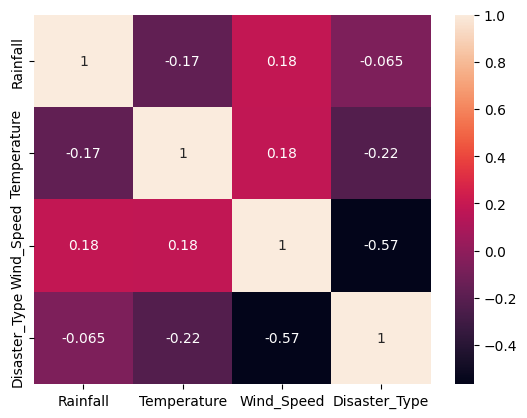

In [10]:
# Exploratory Data Analysis

import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df[['Rainfall','Temperature','Wind_Speed','Disaster_Type']].corr(), annot=True)
plt.show()

In [11]:
#Spliting training and testing data

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2)

print(X_train.shape, X_test.shape)

(73056, 3) (18264, 3)


In [12]:
##Model training
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=50,
    max_depth=4,
    min_samples_split=10,
    random_state=42
)
model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


In [13]:
#prediction
pred = model.predict(X_test)
print(pred[:10])


[0 2 3 0 3 0 0 0 0 0]


In [14]:
#probability
probs = model.predict_proba(X_test)
print(probs[:5])

[[0.86951342 0.06983046 0.02537032 0.0352858 ]
 [0.30406406 0.02251822 0.6401194  0.03329832]
 [0.10801934 0.02731702 0.03979055 0.82487309]
 [0.84253102 0.02726689 0.02484228 0.10535981]
 [0.160668   0.05679763 0.02425052 0.75828385]]


In [15]:
prob = max(probs[0])

In [16]:
# Convert predictions to labels
pred_labels = le.inverse_transform(pred)

# Get confidence
max_probs = np.max(probs, axis=1) * 0.85

# Risk Levels
def risk_level(prob, prediction):
    if prediction in ["Flood", "Cyclone"]:
        return "High Risk"
    elif prob > 0.5:
        return "Medium Risk"
    else:
        return "Low Risk"

risk_levels = [risk_level(p, pred_labels[i]) for i, p in enumerate(max_probs)]

# Create result table
results = X_test.copy()

results['Actual'] = le.inverse_transform(y_test)
results['Predicted'] = pred_labels
results['Confidence'] = max_probs
results['Risk_Level'] = risk_levels

# SHOW OUTPUT
print(results.head(10))


       Rainfall  Temperature  Wind_Speed       Actual    Predicted  \
25448       4.1         31.4        13.8      Cyclone      Cyclone   
64901      14.9         24.8        13.5        Flood    Landslide   
38717       0.0         24.1         9.8  No Disaster  No Disaster   
89200       0.0         30.8        16.1      Cyclone      Cyclone   
7620        0.0         27.5        10.0  No Disaster  No Disaster   
36053       2.5         36.1        23.0      Cyclone      Cyclone   
88699       0.0         30.0        14.5      Cyclone      Cyclone   
17679       0.0         33.8        19.1      Cyclone      Cyclone   
75136       0.2         30.7        16.6      Cyclone      Cyclone   
81087       0.7         20.4        13.2      Cyclone      Cyclone   

       Confidence   Risk_Level  
25448    0.739086    High Risk  
64901    0.544101  Medium Risk  
38717    0.701142  Medium Risk  
89200    0.716151    High Risk  
7620     0.644541  Medium Risk  
36053    0.765218    High Risk 

In [17]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.9265768725361366


In [18]:
places_df= pd.read_csv(r"C:\Users\dronk\OneDrive\Desktop\Capstone Project\places.csv") 
print(places_df.head())

                    Name      Type  Latitude  Longitude
0            AIIMS Delhi  Hospital   28.5672    77.2100
1    Safdarjung Hospital  Hospital   28.5706    77.2070
2     Max Hospital Saket  Hospital   28.5245    77.2066
3  Fortis Hospital Noida  Hospital   28.5670    77.3260
4  Apollo Hospital Delhi  Hospital   28.5416    77.2837


In [19]:
#Getting nearest places

from geopy.distance import geodesic

def get_nearest_places(df, user_location):
    df['distance'] = df.apply(
        lambda row: geodesic(user_location, (row['Latitude'], row['Longitude'])).km,
        axis=1
    )
    return df.sort_values(by='distance').head(5)

In [20]:
importance = model.feature_importances_

pd.Series(importance, index=X.columns).sort_values(ascending=False)

Wind_Speed     0.781824
Rainfall       0.120907
Temperature    0.097269
dtype: float64

In [21]:
results

,Rainfall,Temperature,Wind_Speed,Actual,Predicted,Confidence,Risk_Level
25448,4.1,31.4,13.8,Cyclone,Cyclone,0.739086,High Risk
64901,14.9,24.8,13.5,Flood,Landslide,0.544101,Medium Risk
38717,0.0,24.1,9.8,No Disaster,No Disaster,0.701142,Medium Risk
89200,0.0,30.8,16.1,Cyclone,Cyclone,0.716151,High Risk
7620,0.0,27.5,10.0,No Disaster,No Disaster,0.644541,Medium Risk
...,...,...,...,...,...,...,...
1397,0.0,29.4,7.0,No Disaster,No Disaster,0.625325,Medium Risk
30697,0.8,28.1,24.2,Cyclone,Cyclone,0.739792,High Risk
89347,0.0,32.8,32.2,Cyclone,Cyclone,0.744997,High Risk
57545,0.2,32.3,14.1,Cyclone,Cyclone,0.739503,High Risk


In [22]:
#high risk 
high_risk_cases = results[results['Risk_Level'] == "High Risk"]

In [23]:

print(high_risk_cases.head())

       Rainfall  Temperature  Wind_Speed   Actual Predicted  Confidence  \
25448       4.1         31.4        13.8  Cyclone   Cyclone    0.739086   
89200       0.0         30.8        16.1  Cyclone   Cyclone    0.716151   
36053       2.5         36.1        23.0  Cyclone   Cyclone    0.765218   
88699       0.0         30.0        14.5  Cyclone   Cyclone    0.717870   
17679       0.0         33.8        19.1  Cyclone   Cyclone    0.753382   

      Risk_Level  
25448  High Risk  
89200  High Risk  
36053  High Risk  
88699  High Risk  
17679  High Risk  


In [24]:
for i, row in high_risk_cases.head(3).iterrows():

    print("\n======================")
    print("Predicted:", row['Predicted'])
    print("Confidence:", round(row['Confidence']*100, 2), "%")
    print("Risk Level:", row['Risk_Level'])

    user_location = (28.98, 77.70)

    nearest = get_nearest_places(places_df, user_location)

    print("\nNearby Services:")
    print(nearest[['Name', 'Type', 'distance']])


Predicted: Cyclone
Confidence: 73.91 %
Risk Level: High Risk

Nearby Services:
                              Name      Type   distance
10           Meerut Police Station    Police   0.733803
13             Fire Station Meerut      Fire   0.737937
5         District Hospital Meerut  Hospital   0.798613
6         Subharti Hospital Meerut  Hospital   3.934009
9   Noida Sector 20 Police Station    Police  56.832701

Predicted: Cyclone
Confidence: 71.62 %
Risk Level: High Risk

Nearby Services:
                              Name      Type   distance
10           Meerut Police Station    Police   0.733803
13             Fire Station Meerut      Fire   0.737937
5         District Hospital Meerut  Hospital   0.798613
6         Subharti Hospital Meerut  Hospital   3.934009
9   Noida Sector 20 Police Station    Police  56.832701

Predicted: Cyclone
Confidence: 76.52 %
Risk Level: High Risk

Nearby Services:
                              Name      Type   distance
10           Meerut Police Stati

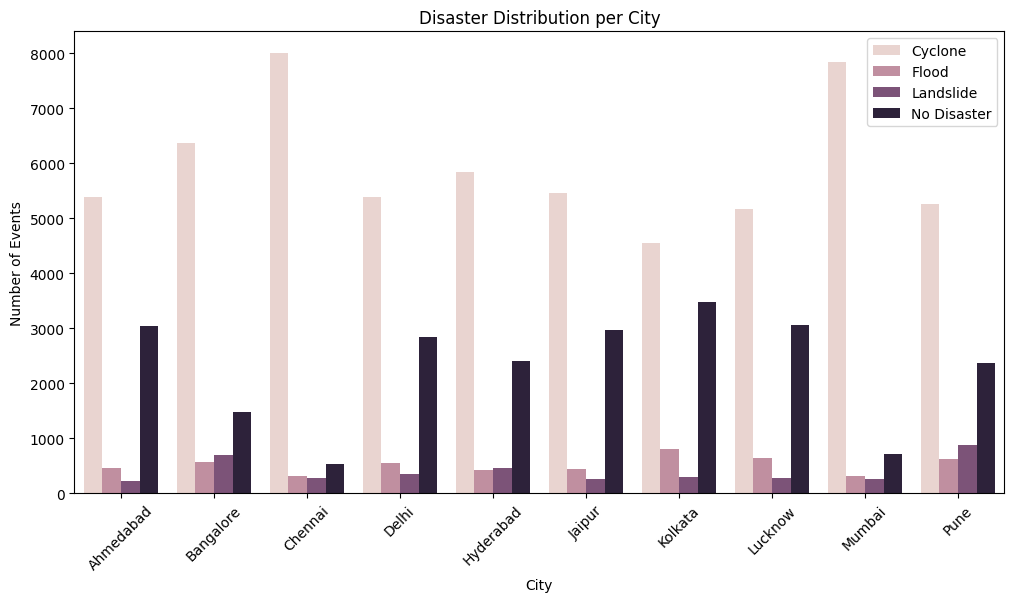

In [25]:
# bar plot of disaster distribution per city
disaster_counts = df.groupby(['city', 'Disaster_Type']).size().reset_index(name='count')

plt.figure(figsize=(12,6))
ax= sns.barplot(x='city', y='count', hue='Disaster_Type', data=disaster_counts)

plt.xticks(rotation=45)
plt.title("Disaster Distribution per City") 
plt.xlabel("City")
plt.ylabel("Number of Events")
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, ['Cyclone', 'Flood', 'Landslide', 'No Disaster'])

plt.show()

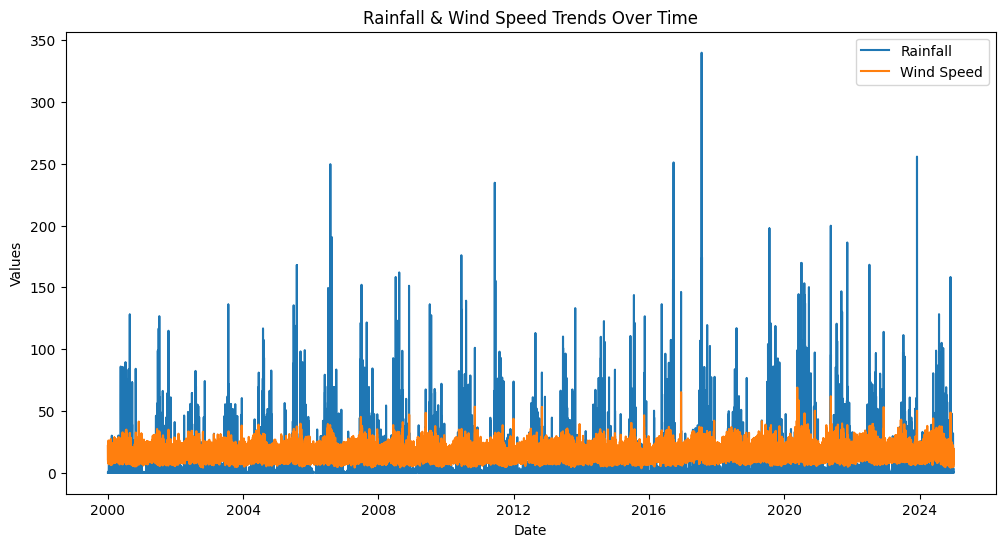

In [26]:

df['date'] = pd.to_datetime(df['date'])
  
df = df.sort_values('date')

plt.figure(figsize=(12,6))

plt.plot(df['date'], df['Rainfall'], label='Rainfall')
plt.plot(df['date'], df['Wind_Speed'], label='Wind Speed')

plt.legend()
plt.title("Rainfall & Wind Speed Trends Over Time")
plt.xlabel("Date")
plt.ylabel("Values")

plt.show()

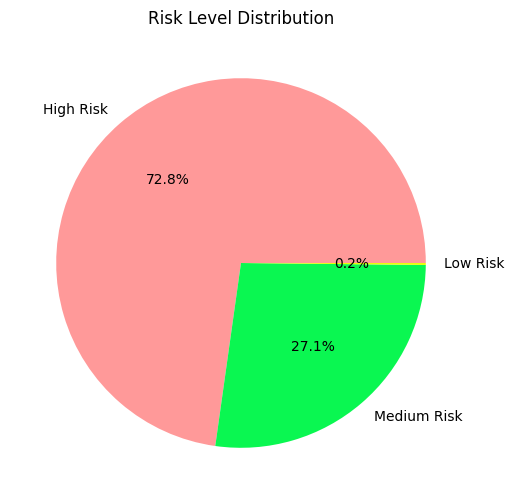

In [27]:
risk_counts = pd.Series(risk_levels).value_counts()

plt.figure(figsize=(6, 6))
plt.pie(risk_counts, labels=risk_counts.index, autopct='%1.1f%%', colors=['#ff9999',"#0af751","#e9fe07"])
plt.title("Risk Level Distribution")
plt.show()

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

# Decision Tree
dt_model = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)

# SVM
svm_model = SVC(probability=True, kernel='rbf', random_state=42)
svm_model.fit(X_train, y_train)
svm_pred = svm_model.predict(X_test)

In [36]:
from sklearn.metrics import accuracy_score

print("Random Forest:", accuracy_score(y_test, pred))
print("Decision Tree:", accuracy_score(y_test, dt_pred))
print("SVM:", accuracy_score(y_test, svm_pred))

Random Forest: 0.9239487516425755
Decision Tree: 0.9238939991239598
SVM: 0.9060446780551905
